In [89]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA


In [90]:
# Load the data
path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/03-DataEnrichment/Week12/Data/adult.csv"
df = pd.read_csv(path)
df.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [92]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


# Data Cleaning

In [93]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [94]:
df = df.replace('?', np.nan)
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [95]:
df.duplicated().sum()

np.int64(52)

In [96]:
# its imbalanced
df['income'].value_counts()

,count
income,
<=50K,37155
>50K,11687


In [97]:
# drop duplicated rows
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [98]:
X = df.drop(columns='income')
y = df['income']
numeric_features = X.select_dtypes('number').columns
categorical_features = X.select_dtypes('object').columns

In [99]:
numeric_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),StandardScaler())

categorical_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),OneHotEncoder(handle_unknown='ignore',sparse_output = False))

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)])

# Questions:
- Target: income
- One row represent one person
- 14 input features and one target
- 48842 row and after deleting duplicated rows we have 48790 row
- Some features may be not important and we can remove them.(we can remove less important features)
- the dataset has missing values, duplicate rows and cat features that need encoding.

# Exploratory Visualization

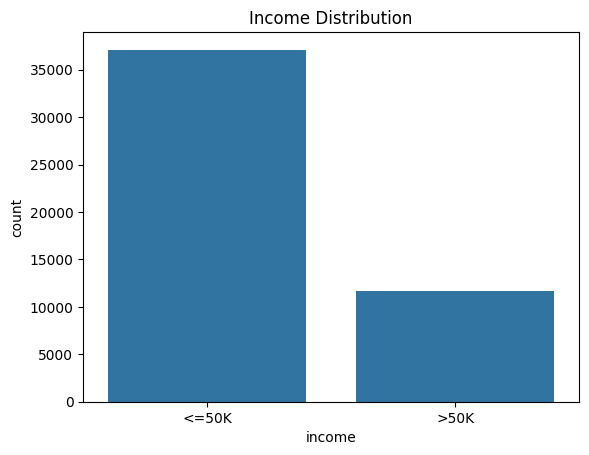

In [100]:
sns.countplot(data = df, x = 'income')
plt.title('Income Distribution');

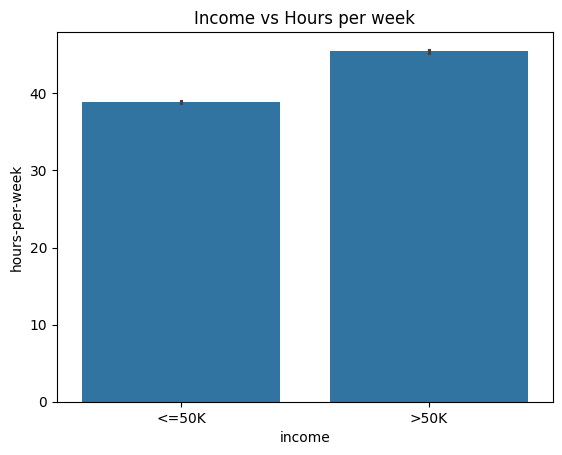

In [101]:
sns.barplot(data = df, x = 'income', y = 'hours-per-week')
plt.title('Income vs Hours per week');

# Model

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [103]:
model = make_pipeline(preprocessor, RandomForestClassifier(random_state=42))
model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [104]:
y_pred = model.predict(X_test)

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      9268
        >50K       0.74      0.62      0.67      2930

    accuracy                           0.86     12198
   macro avg       0.81      0.78      0.79     12198
weighted avg       0.85      0.86      0.85     12198



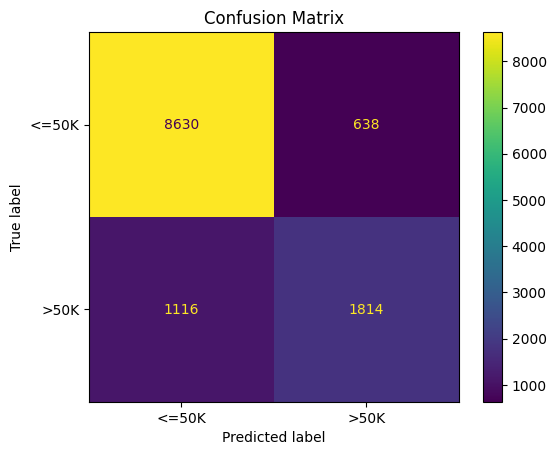

In [105]:
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix');

In [106]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42
)

In [107]:
importance_df = pd.DataFrame()
importance_df["Feature"] = X_test.columns
importance_df["Importance"] = result.importances_mean
importance_df

,Feature,Importance
0,age,0.013970
1,workclass,0.006165
2,fnlwgt,0.001213
3,education,-0.001771
4,educational-num,0.007739
5,marital-status,0.021036
6,occupation,0.013904
7,relationship,0.014478
8,race,0.000951
9,gender,0.000590


In [108]:
top10 = importance_df.sort_values(by='Importance', ascending=False).head(10)
top10

,Feature,Importance
10,capital-gain,0.040646
5,marital-status,0.021036
7,relationship,0.014478
0,age,0.013970
6,occupation,0.013904
11,capital-loss,0.009526
4,educational-num,0.007739
12,hours-per-week,0.007329
1,workclass,0.006165
2,fnlwgt,0.001213


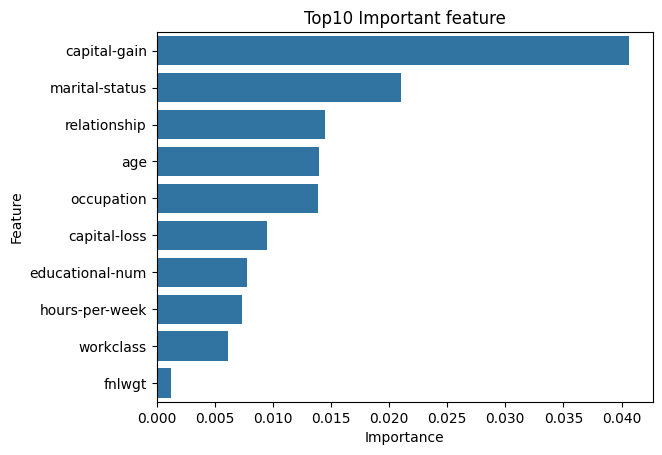

In [109]:
sns.barplot(data = top10, x = 'Importance', y = 'Feature')
plt.title("Top10 Important feature");

# Observation
- The most important features are capital-gain, marital-status, and ralationship.

# Visualization for the most important features

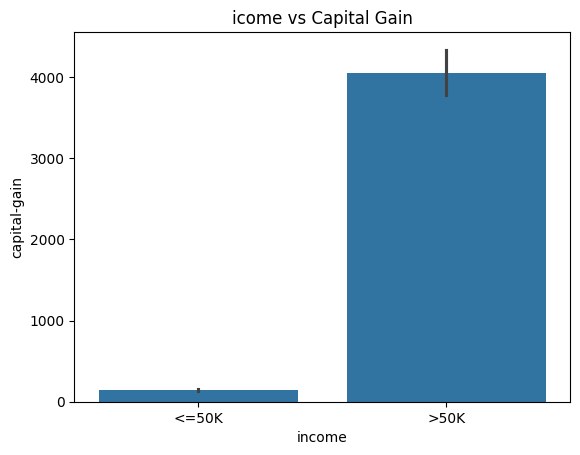

In [110]:
# Capital Gain
sns.barplot(data = df, x = 'income', y = 'capital-gain')
plt.title("icome vs Capital Gain");

- The average captial gain is higher for people earning more than 50k

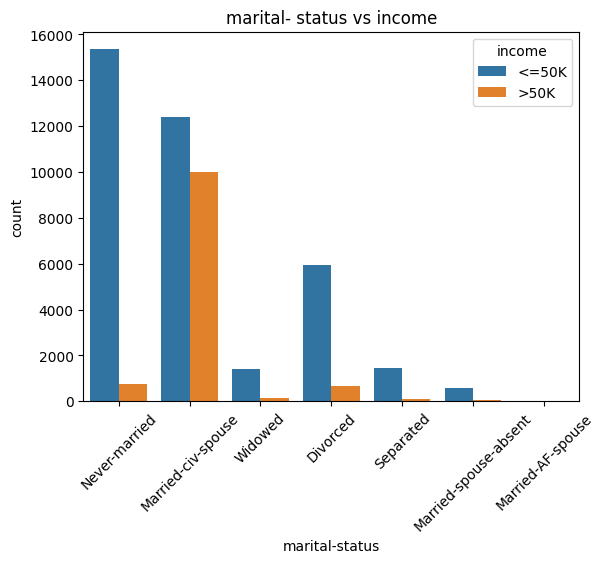

In [111]:
sns.countplot(data = df, x = 'marital-status', hue = 'income')
plt.title('marital- status vs income')
plt.xticks(rotation = 45);

- People who are married are morelikely to earn more than 50k.

# PCA

In [112]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [113]:
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X_train_processed)
test_principal_components = pca.transform(X_test_processed)

In [114]:
pd.DataFrame(data = principal_components, columns = ['PC0', 'PC1', 'PC2']).head()

,PC0,PC1,PC2
0,0.041098,-1.427345,0.143595
1,0.846390,1.360450,0.399924
2,-0.089414,-0.099826,-0.737881
3,-2.316062,0.970191,0.286973
4,-0.529927,-0.496916,0.092622


In [115]:
pca.explained_variance_ratio_

array([0.15037944, 0.10945849, 0.09928887])

In [116]:
pca.explained_variance_ratio_.sum()

np.float64(0.35912680339625713)

In [117]:
pca_train_df = pd.DataFrame(data = principal_components, columns = ['PC0','PC1','PC2'])
pca_test_df = pd.DataFrame(data = test_principal_components, columns = ['PC0','PC1','PC2'])

In [118]:
X_train_df = pd.DataFrame(X_train_processed)
X_test_df = pd.DataFrame(X_test_processed)

In [119]:
X_train_new = pd.concat([X_train_df, pca_train_df], axis=1)
X_test_new = pd.concat([X_test_df, pca_test_df], axis=1)
X_train_new.columns = X_train_new.columns.astype(str)
X_test_new.columns = X_test_new.columns.astype(str)

In [120]:
rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train_new, y_train)
y_pred_pca = rf_pca.predict(X_test_new)

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      9268
        >50K       0.75      0.62      0.68      2930

    accuracy                           0.86     12198
   macro avg       0.82      0.78      0.79     12198
weighted avg       0.85      0.86      0.85     12198



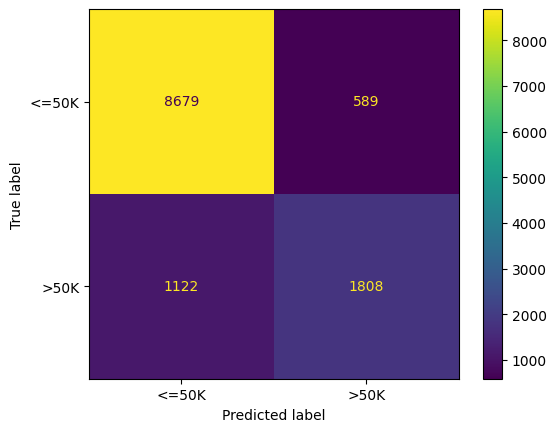

In [121]:
print(classification_report(y_test, y_pred_pca))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_pca)
plt.show()

# Feature Selection

In [122]:
!pip install collinearity

In [123]:
from collinearity import SelectNonCollinear
from sklearn.feature_selection import f_classif

In [124]:
selector = SelectNonCollinear(correlation_threshold=0.75,scoring=f_classif)

In [125]:
selector.fit(X_train_new.values, y_train.values)

In [126]:
non_collinear = selector.get_support()
non_collinear[:5]

[True, True, True, True, True]

In [127]:
selected_mask = selector.get_support()

In [128]:
non_collinear.count(True)

104

In [129]:
non_collinear.count(False)

4

In [130]:
non_collinear_series = pd.Series(
    selector.get_support(),
    index=X_train_new.columns
)
non_collinear_series

,0
0,True
1,True
2,True
3,True
4,True
...,...
103,True
104,True
PC0,True
PC1,True


In [131]:
X_train_selected = X_train_new.loc[:, selected_mask]
X_test_selected = X_test_new.loc[:, selected_mask]

In [132]:
rf_selected = RandomForestClassifier(random_state=42)
rf_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_selected.predict(X_test_selected)

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      9268
        >50K       0.75      0.61      0.68      2930

    accuracy                           0.86     12198
   macro avg       0.82      0.77      0.79     12198
weighted avg       0.85      0.86      0.85     12198



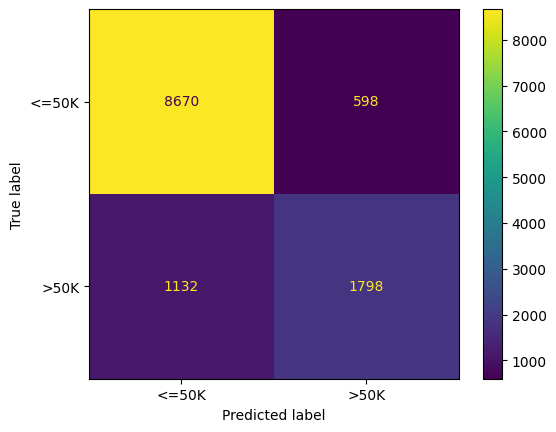

In [133]:
print(classification_report(y_test, y_pred_selected))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_selected)
plt.show()

In [134]:
permutation_result = permutation_importance(
    rf_selected,
    X_test_selected,
    y_test,
    n_repeats=5,
    random_state=42
)

In [136]:
importance_scores = pd.DataFrame({
    'Feature': X_test_selected.columns,
    'Importance': permutation_result.importances_mean
})

In [137]:
top_10_features = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)
top_10_features

,Feature,Importance
10,capital-gain,0.040646
5,marital-status,0.021036
7,relationship,0.014478
0,age,0.013970
6,occupation,0.013904
11,capital-loss,0.009526
4,educational-num,0.007739
12,hours-per-week,0.007329
1,workclass,0.006165
2,fnlwgt,0.001213


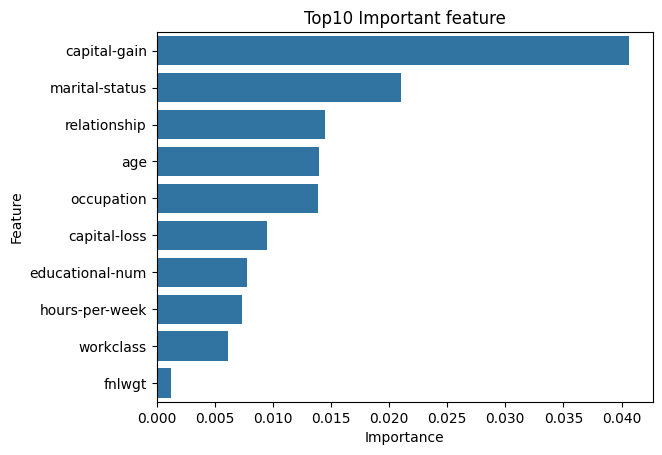

In [138]:
sns.barplot(data = top_10_features, x = 'Importance', y = 'Feature')
plt.title("Top10 Important feature");

### Feature Importance
After applying feature engineering (PCA) and feature selection the model give us the following important features:
- capital-gain
- marital-status
- relationship
- age
- occupation
- capital-loss
- educational-num
- hours-per-week
- workclass
- fnlwgt
Most of these featuress was important in part 1, But the rank of the features changed after applying features selection and feature engineering.
The new features created by PCA were not be from the most important.